In [1]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from astropy.wcs import WCS

In [2]:
import matplotlib.colors as mcolors
original_cmap = plt.get_cmap('Set1')

colors = original_cmap(np.arange(1,6,1))
Set11 = mcolors.ListedColormap(colors)

In [3]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits' 
eightsigmapeaksdat = fits.getdata(fn)
eightsigmapeakdshdr = fits.getheader(fn)
fn1 = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_Npeaks_8sigma.car.fits' 
eightsigmapeakscardat = fits.getdata(fn1)
eightsigmapeakscarhdr = fits.getheader(fn1)

(70.0, 90.0)

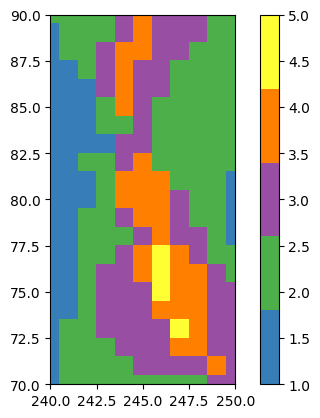

In [4]:
fig, ax = plt.subplots(1,1) 
im = ax.imshow(eightsigmapeakscardat, 
               cmap = Set11, vmin =1, vmax = 5,
               origin = 'lower'
              )
plt.colorbar(im)
ax.set_xlim(240,250)
ax.set_ylim(70,90)

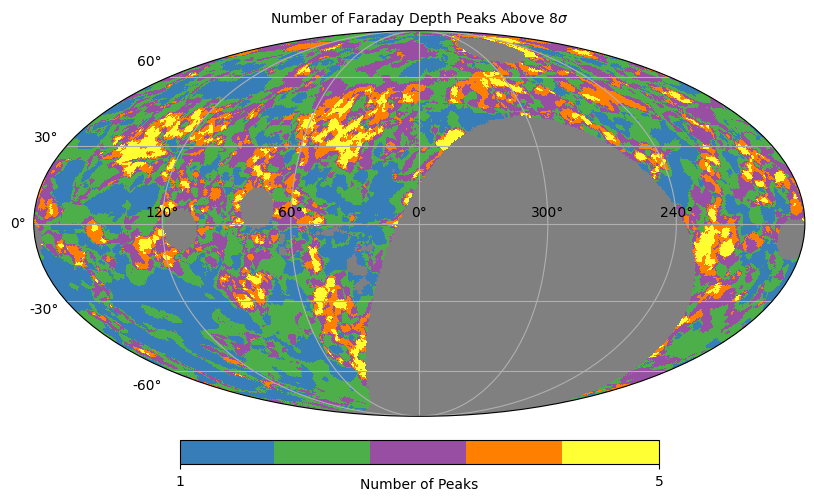

In [5]:
projview(
    eightsigmapeaksdat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = Set11,
    min = 1, 
    max = 5,
    unit = r'Number of Peaks',
    title = r'Number of Faraday Depth Peaks Above 8$\sigma$', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [18]:
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_Npeaks_8sigma.car.fits'
Npeakscardat = fits.getdata(fn)
Npeakscarhdr = fits.getheader(fn)

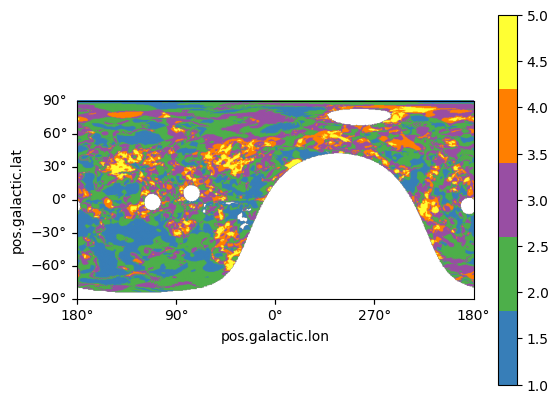

In [29]:
fig, ax = plt.subplots(1,1, subplot_kw={'projection': wcs.celestial})
im0 = ax.imshow(Npeakscardat, origin='lower', cmap = Set11, vmin=1, vmax=5)
plt.colorbar(im0)
plt.show()

In [6]:
#loading clean Faraday Depth Cube for spectra from DRAGONS
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_FDF_clean_tot_Kgal.car.fits'
FDcleandat = fits.getdata(fn) 
FDcleanhdr = fits.getheader(fn)

In [7]:
#loading dirty Faraday Depth Cube for spectra
fn = '/srv/data/dragons/dragons-canfar-Nov2025/faraday_synthesis/dragons_FDF_tot_dirty_Kgal.car.fits'
FDdirtydat = fits.getdata(fn)
FDdirtyhdr = fits.getheader(fn)

In [8]:
wcs = WCS(FDcleanhdr)
wcs

WCS Keywords

Number of WCS axes: 3
CTYPE : 'GLON-CAR' 'GLAT-CAR' 'FDEP' 
CRVAL : 0.0 0.0 0.0 
CRPIX : 360.5 180.5 401.0 
PC1_1 PC1_2 PC1_3  : 1.0 0.0 0.0 
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0 
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0 
CDELT : -0.5 0.5 0.5 
NAXIS : 720  360  801

In [9]:
FDcleanhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                  801                                                  
COORDSYS= 'Galactic '          / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'K/RMSF  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                   

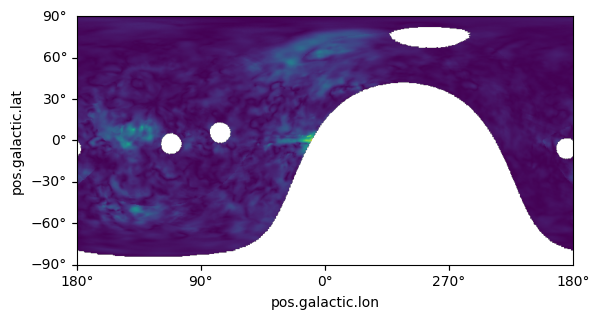

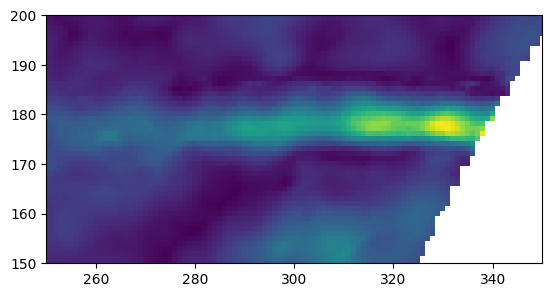

In [15]:
fig, ax = plt.subplots(1,1, subplot_kw={'projection': wcs.celestial})
im0 = ax.imshow(FDcleandat[100], origin='lower')
plt.show()
fig, ax = plt.subplots(1,1)
im1 = ax.imshow(FDcleandat[216], origin='lower')
ax.set_ylim(150,200)
ax.set_xlim(250, 350)
plt.show()
# ax.set_xlim(50, 100) 
# ax.set_ylim(160, 210)

In [11]:
x = 246
y = 75
cleanspectra = FDcleandat[:, x, y] 
dirtyspectra = FDdirtydat[:, x, y]

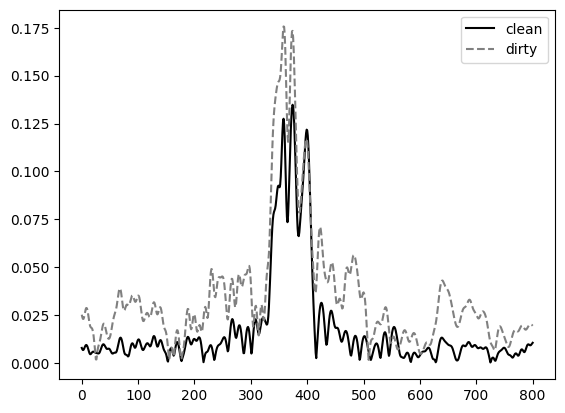

In [12]:
fig, axs = plt.subplots() 
axs.plot(cleanspectra, label = 'clean', color = 'black') 
axs.plot(dirtyspectra, label = 'dirty', linestyle = 'dashed', color = 'grey')
plt.legend()
ax.set_title('Faraday Depth Spectra of 

In [13]:
x = 83 
y = 198
cleanspectra = FDcleandat[:, x, y]
dirtyspectra = FDdirtydat[:, x, y] 


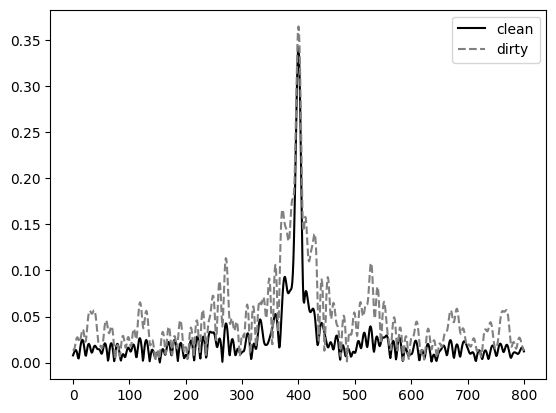

In [14]:
fig, axs = plt.subplots() 
axs.plot(cleanspectra, label = 'clean', color = 'black') 
axs.plot(dirtyspectra, label = 'dirty', linestyle = 'dashed', color = 'grey')
plt.legend()